In [1]:
from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance


def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap="gray", vmin=-200, vmax=500)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()

In [2]:
in_dir = "data/"
ct = dicom.dcmread(in_dir + 'Training.dcm')
img = ct.pixel_array
print(img.shape)
print(img.dtype)

(512, 512)
int16


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/1420818243.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img, vmin=35, vmax=75, cmap='gray')
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/1420818243.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


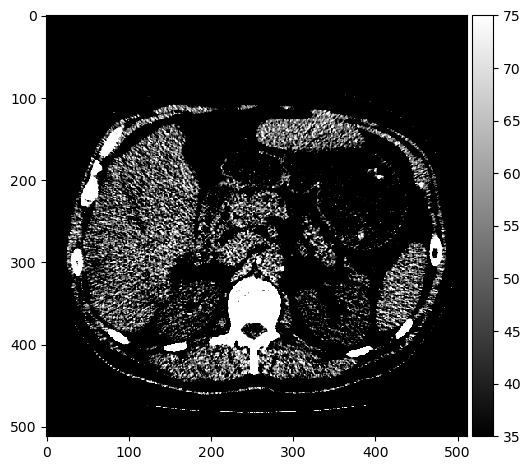

In [15]:
# 1. The spleen typically has HU units in the range of 0 to 150. 
# Try to make a good visualization of the CT scan and spleen using 
# (replace the question marks with values):

io.imshow(img, vmin=35, vmax=75, cmap='gray')
io.show()

In [20]:
spleen_roi = io.imread(in_dir + 'SpleenROI.png')
# convert to boolean image
spleen_mask = spleen_roi > 0
spleen_values = img[spleen_mask]

bone_roi = io.imread(in_dir + 'BoneROI.png')
# convert to boolean image
bone_mask = bone_roi > 0
bone_values = img[bone_mask]

fat_roi = io.imread(in_dir + 'FatROI.png')
# convert to boolean image
fat_mask = fat_roi > 0
fat_values = img[fat_mask]

kidney_roi = io.imread(in_dir + 'KidneyROI.png')
# convert to boolean image
kidney_mask = kidney_roi > 0
kidney_values = img[kidney_mask]

liver_roi = io.imread(in_dir + 'LiverROI.png')
# convert to boolean image
liver_mask = liver_roi > 0
liver_values = img[liver_mask]

In [14]:
# 2. Compute the average and standard deviation of the 
# Hounsfield units found in the spleen in the training image. 
# Do they correspond to the values found in the above figure?
spleen_mean = np.mean(spleen_values)
spleen_std = np.std(spleen_values)
print(f"Spleen HU mean: {spleen_mean:.2f}")
print(f"Spleen HU std: {spleen_std:.2f}")


Spleen HU mean: 49.48
Spleen HU std: 15.00


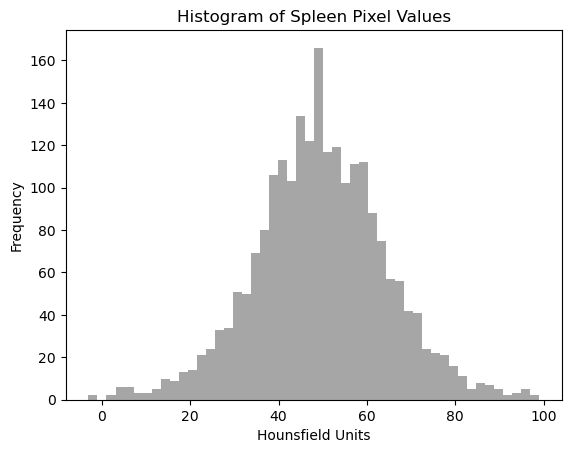

In [ ]:
# 3. Plot a histogram of the pixel values of the spleen. 
# Does it look like they are Gaussian distributed?
plt.hist(spleen_values, bins=50, color='gray', alpha=0.7)
plt.title('Histogram of Spleen Pixel Values')
plt.xlabel('Hounsfield Units')
plt.ylabel('Frequency')
plt.show()

# Yes, the histogram appears to be approximately Gaussian distributed,

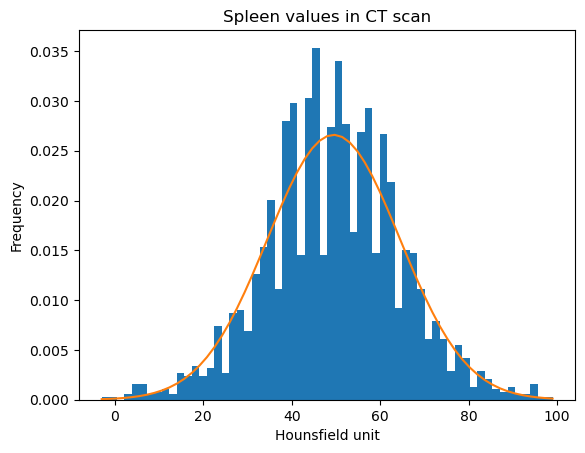

In [17]:
n, bins, patches = plt.hist(spleen_values, 60, density=1)
pdf_spleen = norm.pdf(bins, spleen_mean, spleen_std)
plt.plot(bins, pdf_spleen)
plt.xlabel('Hounsfield unit')
plt.ylabel('Frequency')
plt.title('Spleen values in CT scan')
plt.show()

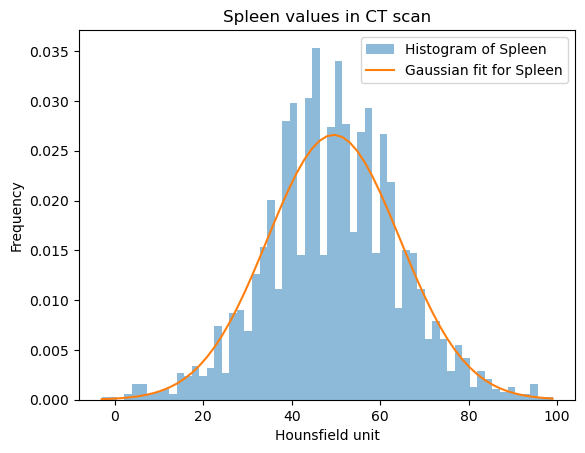

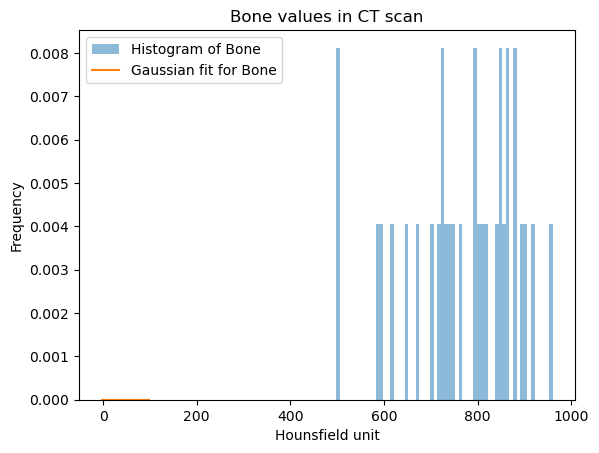

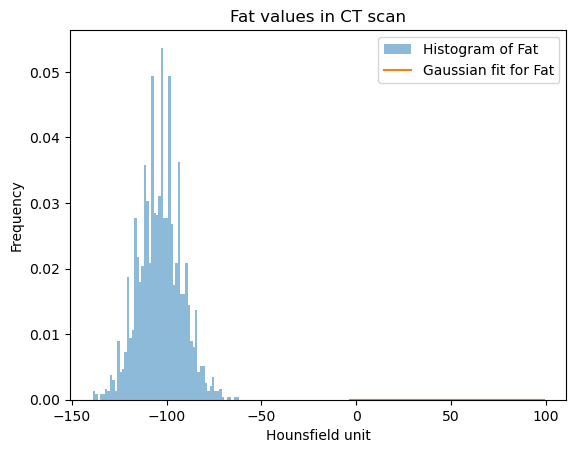

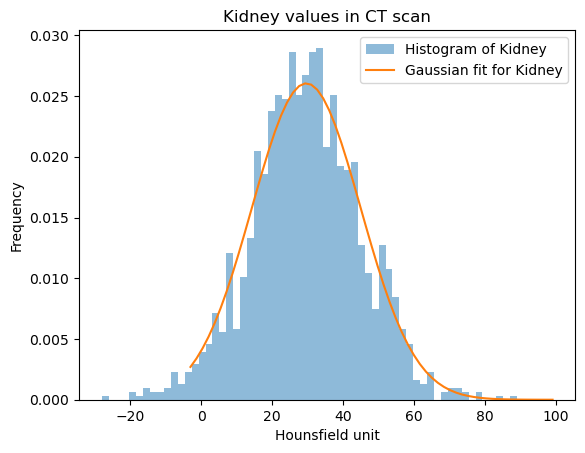

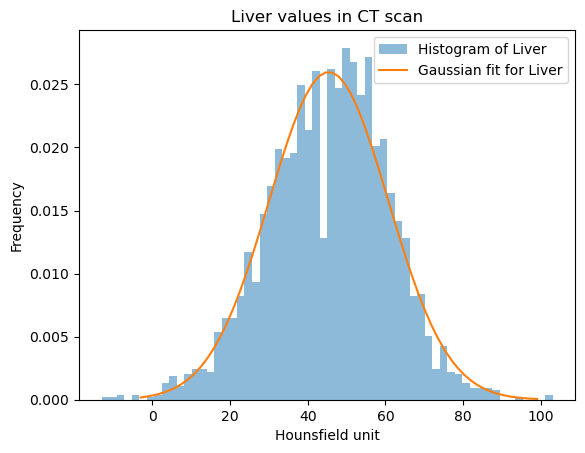

In [ ]:
# 4.  Plot histograms and their fitted Gaussians of several of 
# the tissues types.
# Do they all look like they are Gaussian distributed?

tissue_types = {
    "Spleen": spleen_values,
    "Bone": bone_values,
    "Fat": fat_values,
    "Kidney": kidney_values,
    "Liver": liver_values
}

for tissue, values in tissue_types.items():
    plt.hist(values, bins=60, density=1, alpha=0.5, label=f'Histogram of {tissue}')
    pdf = norm.pdf(bins, np.mean(values), np.std(values))
    plt.plot(bins, pdf, label=f'Gaussian fit for {tissue}')
    plt.xlabel('Hounsfield unit')
    plt.ylabel('Frequency')
    plt.title(f'{tissue} values in CT scan')
    plt.legend()
    plt.show()

# Bones show a clear non-Gaussian distribution.

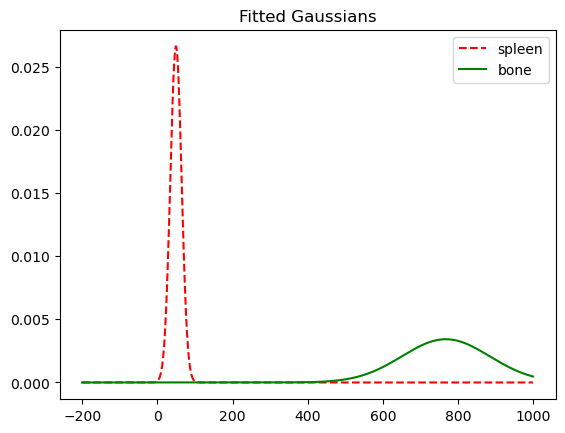

In [22]:
# Hounsfield unit limits of the plot
min_hu = -200
max_hu = 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
pdf_spleen = norm.pdf(hu_range, spleen_mean, spleen_std)
pdf_bone = norm.pdf(hu_range, np.mean(bone_values), np.std(bone_values))
plt.plot(hu_range, pdf_spleen, 'r--', label="spleen")
plt.plot(hu_range, pdf_bone, 'g', label="bone")
plt.title("Fitted Gaussians")
plt.legend()
plt.show()

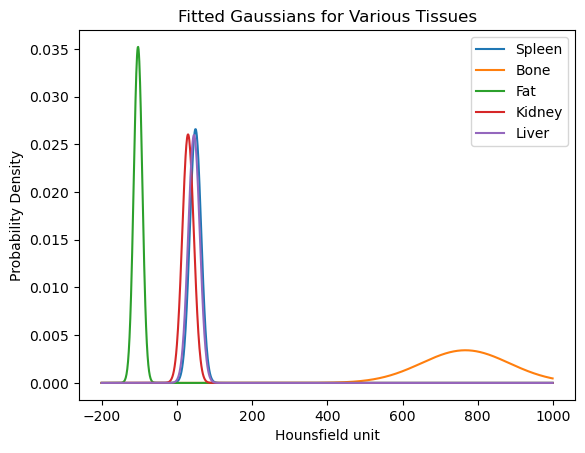

In [ ]:
# 5.  Plot the fitted Gaussians of bone, fat, kidneys, liver and spleen. 
# What classes are easy to seperate and which classes are hard to seperate?
tissue_pdfs = {
    "Spleen": (spleen_mean, spleen_std),
    "Bone": (np.mean(bone_values), np.std(bone_values)),
    "Fat": (np.mean(fat_values), np.std(fat_values)),
    "Kidney": (np.mean(kidney_values), np.std(kidney_values)),
    "Liver": (np.mean(liver_values), np.std(liver_values))
}
for tissue, (mean, std) in tissue_pdfs.items():
    pdf = norm.pdf(hu_range, mean, std)
    plt.plot(hu_range, pdf, label=tissue)
plt.title("Fitted Gaussians for Various Tissues")
plt.xlabel('Hounsfield unit')
plt.ylabel('Probability Density')
plt.legend()
plt.show()
# Bone and fat are easy to separate due to their distinct HU ranges.
# Spleen, kidney, and liver have overlapping HU ranges, making them harder to separate


In [ ]:
# 6. Define the classes that we aim at classifying. 
# Perhaps some classes should be combined into one class?

class_mapping = {
    "Spleen": "Spleen",
    "Bone": "Bone",
    "Fat": "Fat",
    "Kidney": "Kidney",
    "Liver": "Liver"
}
# Depending on the application, one might consider combining
# kidney and liver into an "Abdominal Organs" class due to their similar HU values
# or combining all soft tissues into a single class if differentiation is not critical.


In the **minimum distance classifier** the pixel value class ranges are defined using the average values of the training values. If you have two classes, the threshold between them is defined as the mid-point between the two class value averages.

In the following, we will define four classes: **background, fat, soft tissue and bone**, where soft-tissue is a combination of the values of the spleen, liver and kidneys. 
We manually set the threshold for background to -200. So all pixels below -200 are set to background.

**Exercise 7**: *Compute the class ranges defining fat, soft tissue and bone.*

In [26]:
# 7. Compute the class ranges defining fat, soft tissue and bone.
soft_values = np.concatenate([spleen_values, kidney_values, liver_values])

class_ranges = {
    "Fat": (np.min(fat_values), np.max(fat_values)),
    "Soft Tissue": (np.min(soft_values), np.max(soft_values)),
    "Bone": (np.min(bone_values), np.max(bone_values))
}

# Threshold between fat and soft tissue
t_fat_soft = (np.max(fat_values) + np.min(soft_values)) / 2
# Threshold between soft tissue and bone
t_soft_bone = (np.max(soft_values) + np.min(bone_values)) / 2

t_background = -200
fat_img = (img > t_background) & (img <= t_fat_soft)

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


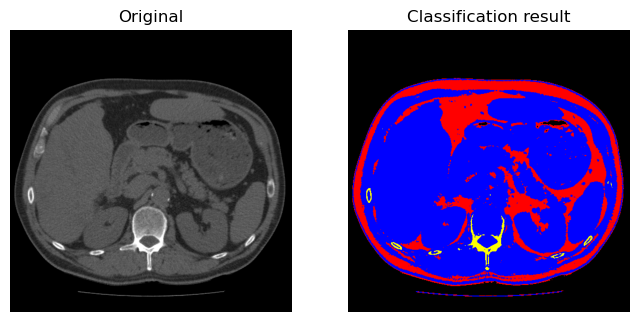

In [ ]:
# 8. Create class images: fat_img, soft_img and bone_img representing the fat, 
# soft tissue and bone found in the image.

fat_img = (img > t_background) & (img <= t_fat_soft)
soft_img = (img > t_fat_soft) & (img <= t_soft_bone)
bone_img = (img > t_soft_bone)

# 9. Visualize your classification result and compare it to 
# the anatomical image in the start of the exercise. 
# Does your results look plausible?
label_img = fat_img + 2 * soft_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, 'Classification result')

# Yes, the classification results look plausible with fat, soft tissue, and bone
# regions reasonably well identified in the CT image.

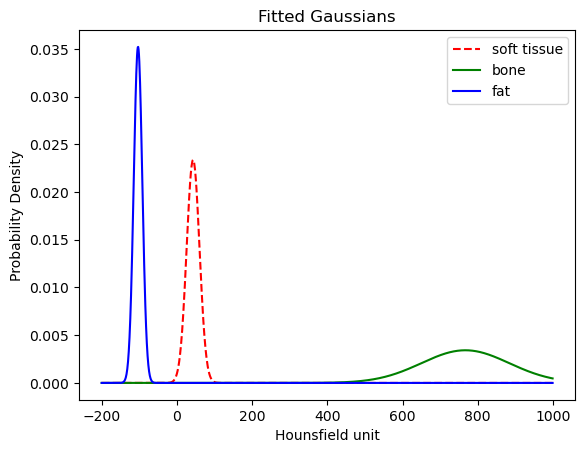

In [29]:
# 9. the second: Plot the fitted Gaussians of the training values 
# and manually find the intersection between the curves.
min_hu = -200
max_hu = 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
pdf_soft = norm.pdf(hu_range, np.mean(soft_values), np.std(soft_values))
pdf_bone = norm.pdf(hu_range, np.mean(bone_values), np.std(bone_values))
pdf_fat = norm.pdf(hu_range, np.mean(fat_values), np.std(fat_values))
plt.plot(hu_range, pdf_soft, 'r--', label="soft tissue")
plt.plot(hu_range, pdf_bone, 'g', label="bone")
plt.plot(hu_range, pdf_fat, 'b', label="fat")
plt.title("Fitted Gaussians")
plt.xlabel('Hounsfield unit')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

Fat mean,std: -103.39037725533078 11.323207120153308
Soft mean,std: 43.00880789673501 17.067828814221958
Bone mean,std: 766.9375 116.56353886936515
Intersections fat <-> soft: [ 44.461087 392.498236]
Intersections soft <-> bone: [-140.628467   86.33351 ]


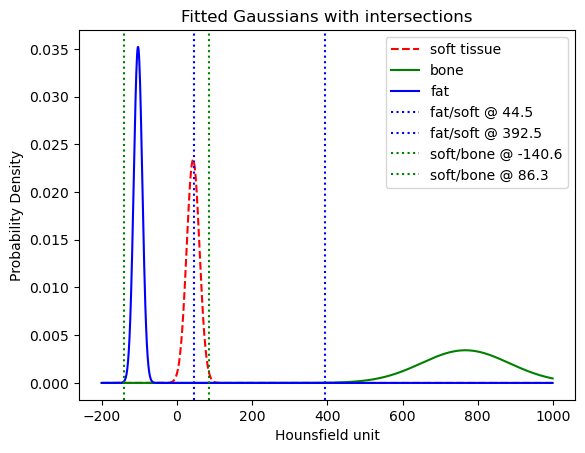

In [31]:
# Compute intersections of two normal PDFs and plot vertical lines at intersection points
def gaussian_intersections(mu1, s1, mu2, s2):
    # solve for x where N(mu1,s1)(x) == N(mu2,s2)(x)
    # handle equal stds (gives midpoint)
    if np.isclose(s1, s2):
        return np.array([(mu1 + mu2) / 2.0])
    a = (1.0 / (2.0 * s2**2)) - (1.0 / (2.0 * s1**2))
    b = (mu1 / (s1**2)) - (mu2 / (s2**2))
    c = (mu2**2 / (2.0 * s2**2)) - (mu1**2 / (2.0 * s1**2)) + np.log(s2 / s1)
    # convert ax^2 + bx + c = 0  (note b here corresponds to 2nd term after simplification)
    # coefficients for standard quadratic: A = a, B = -b? careful: derived above gives
    # using direct quadratic formula from derivation:
    A = a
    B = -b
    C = c
    disc = B**2 - 4*A*C
    if disc < 0:
        return np.array([])  # no real intersection
    roots = np.array([(-B + np.sqrt(disc)) / (2*A), (-B - np.sqrt(disc)) / (2*A)])
    # return unique real roots
    return np.unique(np.round(roots, 6))

# get parameters
mu_soft, s_soft = np.mean(soft_values), np.std(soft_values)
mu_fat,  s_fat  = np.mean(fat_values),  np.std(fat_values)
mu_bone, s_bone = np.mean(bone_values), np.std(bone_values)

# compute intersections
ints_fat_soft = gaussian_intersections(mu_fat, s_fat, mu_soft, s_soft)
ints_soft_bone = gaussian_intersections(mu_soft, s_soft, mu_bone, s_bone)

print("Fat mean,std:", mu_fat, s_fat)
print("Soft mean,std:", mu_soft, s_soft)
print("Bone mean,std:", mu_bone, s_bone)
print("Intersections fat <-> soft:", ints_fat_soft)
print("Intersections soft <-> bone:", ints_soft_bone)

# replot fitted gaussians and mark intersections
plt.figure()
plt.plot(hu_range, norm.pdf(hu_range, mu_soft, s_soft), 'r--', label='soft tissue')
plt.plot(hu_range, norm.pdf(hu_range, mu_bone, s_bone), 'g',   label='bone')
plt.plot(hu_range, norm.pdf(hu_range, mu_fat, s_fat), 'b',    label='fat')
for x in ints_fat_soft:
    plt.axvline(x, color='blue', linestyle=':', label=f'fat/soft @ {x:.1f}')
for x in ints_soft_bone:
    plt.axvline(x, color='green', linestyle=':', label=f'soft/bone @ {x:.1f}')
plt.title("Fitted Gaussians with intersections")
plt.xlabel('Hounsfield unit')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


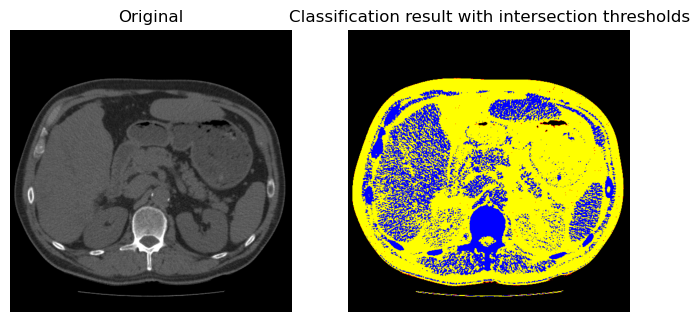

In [ ]:
# 10 Use the same technique as in exercise 7, 8 and 9 
# to visualize your classification results. 
# Did it change compared to the minimum distance classifier?

t_fat_soft = ints_fat_soft[0]
t_soft_bone = ints_soft_bone[0]
fat_img = (img > t_background) & (img <= t_fat_soft)
soft_img = (img > t_fat_soft) & (img <= t_soft_bone)
bone_img = (img > t_soft_bone)
label_img = fat_img + 2 * soft_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, 'Classification result with intersection thresholds')
# yes i think it changed a bit compared to the minimum distance classifier it seems to get a bit worse

In [ ]:
# 11.  Use norm.pdf to find the optimal class ranges between 
# fat, soft tissue and bone.

def find_optimal_thresholds(mu1, s1, mu2, s2):
    # Find the single threshold where the two Gaussian PDFs intersect.
    # We sample finely, find sign changes of (pdf1 - pdf2), linearly interpolate roots,
    # then choose the root that lies between the two means (if any).
    x = np.linspace(-200, 1000, 100001)
    pdf1 = norm.pdf(x, mu1, s1)
    pdf2 = norm.pdf(x, mu2, s2)
    diff = pdf1 - pdf2

    # locate sign changes
    idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if idx.size == 0:
        return None

    roots = []
    for i in idx:
        x0, x1 = x[i], x[i+1]
        y0, y1 = diff[i], diff[i+1]
        # linear interpolation for root
        root = x0 - y0 * (x1 - x0) / (y1 - y0)
        roots.append(root)
    roots = np.array(roots)

    # prefer root between the two means
    low, high = min(mu1, mu2), max(mu1, mu2)
    candidates = roots[(roots > low) & (roots < high)]
    if candidates.size > 0:
        return float(candidates[0])

    # otherwise return the root closest to the midpoint of the means
    midpoint = 0.5 * (mu1 + mu2)
    return float(roots[np.argmin(np.abs(roots - midpoint))])

optimal_fat_soft = find_optimal_thresholds(mu_fat, s_fat, mu_soft, s_soft)
optimal_soft_bone = find_optimal_thresholds(mu_soft, s_soft, mu_bone, s_bone)

print("Optimal fat/soft threshold:", optimal_fat_soft)
print("Optimal soft/bone threshold:", optimal_soft_bone)

Optimal fat/soft threshold: -44.46108381366866
Optimal soft/bone threshold: 140.62847141431482


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/3439940164.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(spleen_label_colour)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/3439940164.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


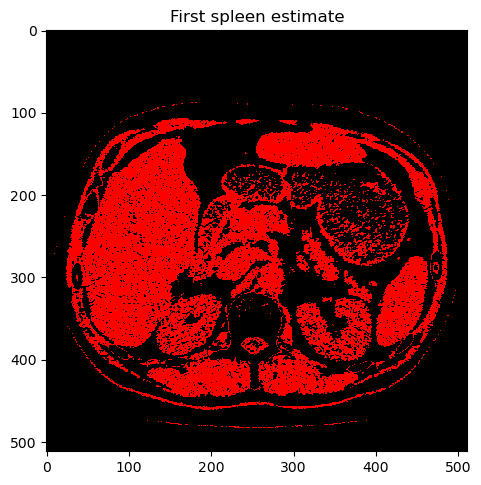

In [35]:
# 11. the second:  Inspect the values of the spleen as in exercise 3 and 
# select a lower and upper threshold to create a spleen class range.
t_1 = spleen_mean - 2 * spleen_std
t_2 = spleen_mean + 2 * spleen_std

spleen_estimate = (img > t_1) & (img < t_2)
spleen_label_colour = color.label2rgb(spleen_estimate)
io.imshow(spleen_label_colour)
plt.title("First spleen estimate")
io.show()


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/2759926904.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(opened)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/2759926904.py:14: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


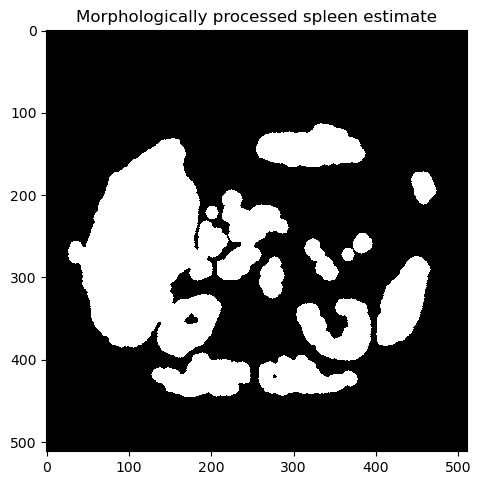

In [68]:
# 12. Use the above morphological operations to seperate the 
# spleen from other organs and close holes.
# Change the values where there are question marks to 
# change the size of the used structuring elements.

footprint = disk(2)
closed = binary_closing(spleen_estimate, footprint)

footprint = disk(8)
opened = binary_opening(closed, footprint)

io.imshow(opened)
plt.title("Morphologically processed spleen estimate")
io.show()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


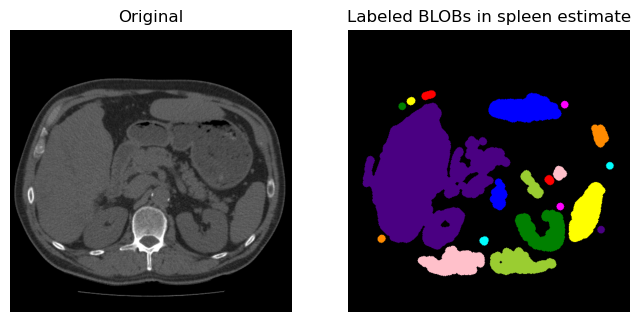

In [50]:
# 12. the second: Use the methods from BLOB analysis to compute BLOB features 
# for every seperated BLOB in the image. You can for example start by
label_img = measure.label(opened)
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, 'Labeled BLOBs in spleen estimate')

In [ ]:
# 13.  Inspect the labeled image and validate the success 
# of separating the spleen from the other objects.

# It is successful

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


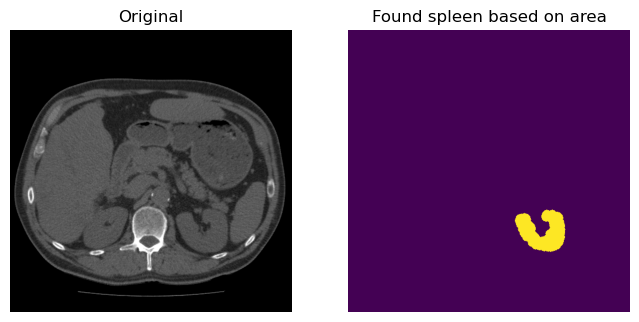

In [59]:
# 14.  Extend the method above to include several BLOB features. 
# For example area and perimeter. 
# Find the combination of features and feature 
# value limits that will result in only the spleen remaining.

min_area = 4000
max_area = 5000

min_perimeter = 350
max_perimeter = 450

# Create a copy of the label_img
label_img_filter = label_img.copy()
for region in measure.regionprops(label_img):
    # Find the areas that do not fit our criteria
    if region.area > max_area or region.area < min_area:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0

    # Find the perimeters that do not fit our criteria
    if region.perimeter > max_perimeter or region.perimeter < min_perimeter:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0


# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img, i_area, 'Found spleen based on area')

In [174]:
# 15. Create a function spleen_finder(img) that takes as input a CT image 
# and returns a binary image, where the pixels with value 1 represent the 
# spleen and the pixels with value 0 everything else.
min_area = 4000
max_area = 5000

min_perimeter = 350
max_perimeter = 500

def spleen_finder(img):
    # Thresholding based on spleen HU range
    t_1 = spleen_mean - 2 * spleen_std
    t_2 = spleen_mean + 2 * spleen_std
    spleen_estimate = (img > t_1) & (img < t_2)

    # Morphological operations
    footprint = disk(2)
    closed = binary_closing(spleen_estimate, footprint)
    footprint = disk(11)
    opened = binary_opening(closed, footprint)
    show_comparison(img, opened, 'Morphologically processed spleen estimate')

    # BLOB analysis to filter by area
    label_img = measure.label(opened)
    label_img_filter = label_img.copy()
    for region in measure.regionprops(label_img):
        if region.area > max_area or region.area < min_area:
            for cords in region.coords:
                label_img_filter[cords[0], cords[1]] = 0
                continue
        
        if region.perimeter > max_perimeter or region.perimeter < min_perimeter:
            for cords in region.coords:
                label_img_filter[cords[0], cords[1]] = 0
                continue


    spleen_binary = label_img_filter > 0
    return spleen_binary

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


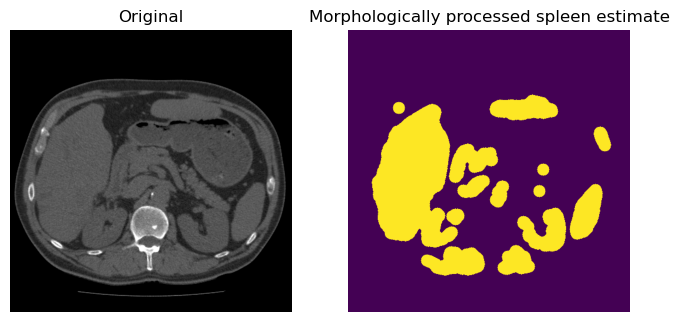

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


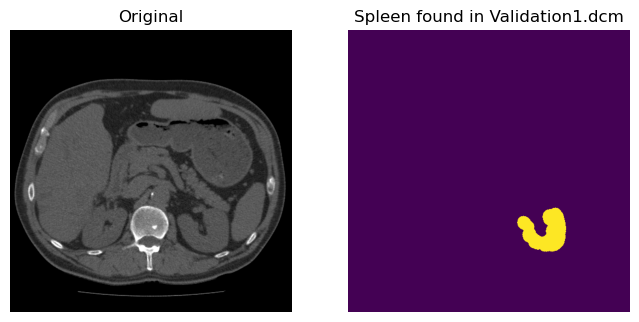

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


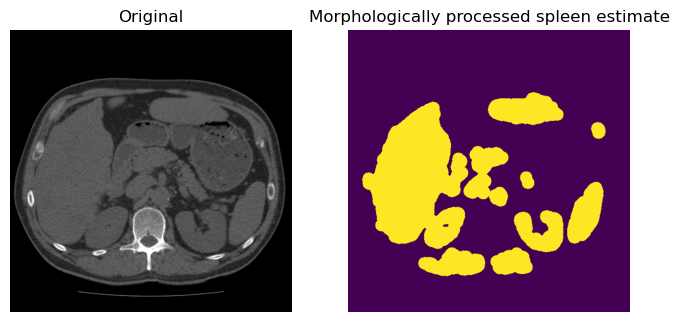

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


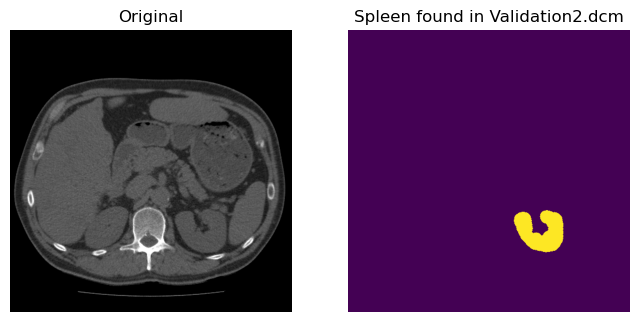

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


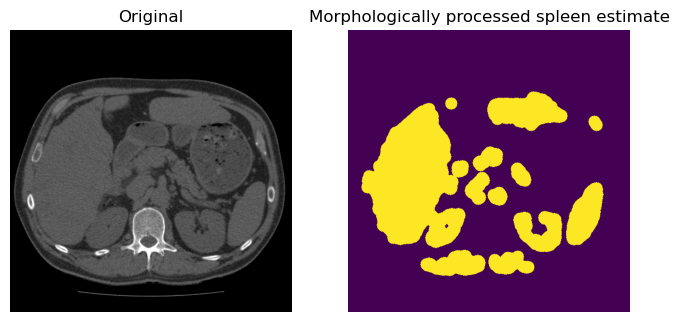

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


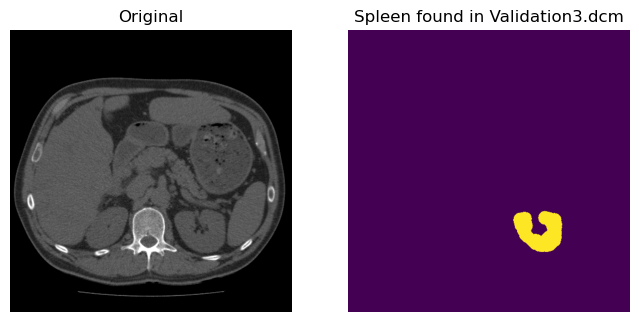

In [175]:
# 16. Test your function on the images called Validation1.dcm, 
# Validation2.dcm and Validation3.dcm. 
# Do you succeed in finding the spleen in all the validation images?

for i in range(1, 4):
    ct_val = dicom.dcmread(in_dir + f'Validation{i}.dcm')
    img_val = ct_val.pixel_array
    spleen_result = spleen_finder(img_val)
    show_comparison(img_val, spleen_result, f'Spleen found in Validation{i}.dcm')
    
# I did find the spleen in all validation images


In [90]:
ground_truth_img = io.imread(in_dir + 'Validation1_spleen.png')
gt_bin = ground_truth_img > 0
dice_score = 1 - distance.dice(i_area.ravel(), gt_bin.ravel())
print(f"DICE score {dice_score}")

DICE score 0.0


In [ ]:
# 17. Compute the DICE score for your found spleen segmentations compared 
# to the ground truth segmentations for the three validation images. 
# How high DICE scores do you achieve?

for i in range(1, 4):
    ct_val = dicom.dcmread(in_dir + f'Validation{i}.dcm')
    img_val = ct_val.pixel_array
    spleen_result = spleen_finder(img_val)

    ground_truth_img = io.imread(in_dir + f'Validation{i}_spleen.png')
    gt_bin = ground_truth_img > 0
    dice_score = 1 - distance.dice(spleen_result.ravel(), gt_bin.ravel())
    print(f"DICE score for Validation{i}.dcm: {dice_score}")
    
# for some reason I only get a dice score of 0.0 i need to fix this later

DICE score for Validation1.dcm: 0.0
DICE score for Validation2.dcm: 0.0
DICE score for Validation3.dcm: 0.0


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


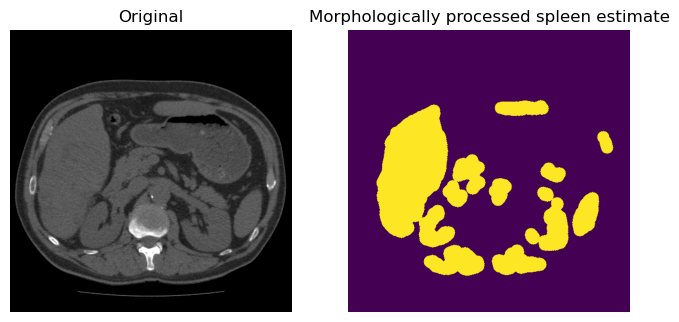

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


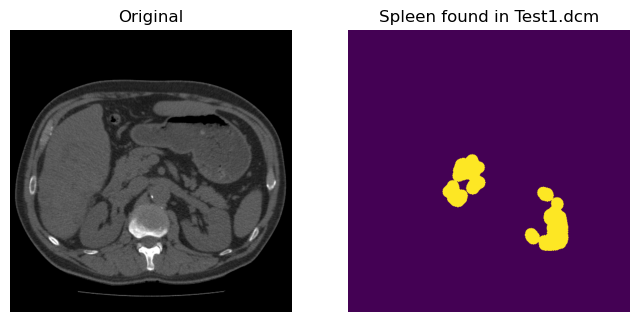

DICE score for Test1.dcm: 0.0


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


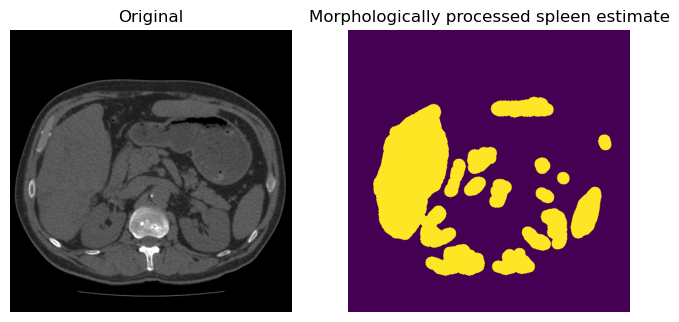

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


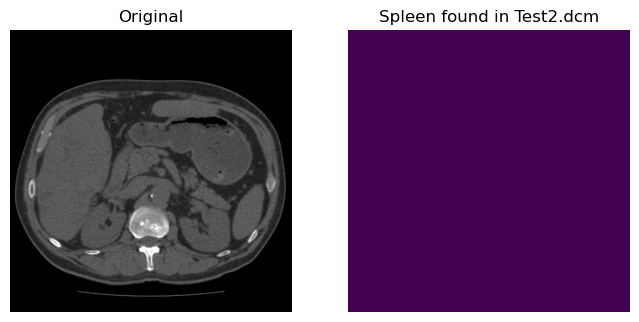

DICE score for Test2.dcm: 0.0


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


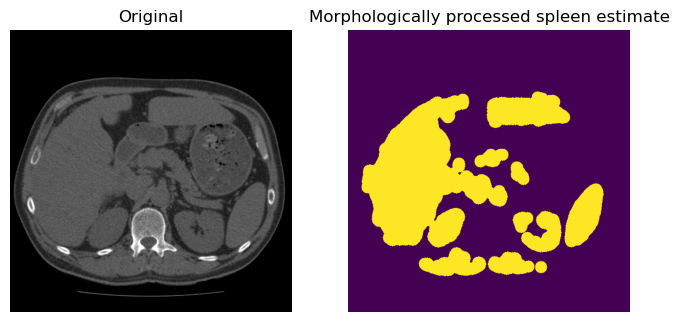

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_47430/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


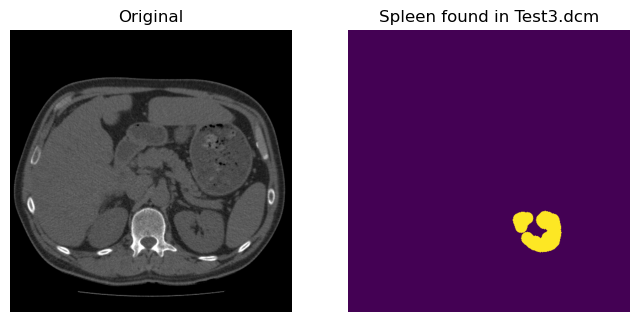

DICE score for Test3.dcm: 0.0


In [176]:
# 18. Use your spleen finder program to find the spleen on the three test
# images and compute the DICE score. What is the result of your independent 
# test?

for i in range(1, 4):
    ct_test = dicom.dcmread(in_dir + f'Test{i}.dcm')
    img_test = ct_test.pixel_array
    spleen_result = spleen_finder(img_test)
    show_comparison(img_test, spleen_result, f'Spleen found in Test{i}.dcm')

    ground_truth_img = io.imread(in_dir + f'Test{i}_spleen.png')
    gt_bin = ground_truth_img > 0
    dice_score = 1 - distance.dice(spleen_result.ravel(), gt_bin.ravel())
    print(f"DICE score for Test{i}.dcm: {dice_score}")